## 1) Imports and Setup


In [2]:
from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity

DATA_PATH = Path("data/raw/jobs.csv")
REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


## 2) Load Data


2.1 load dataset

In [3]:
df = pd.read_csv("/Users/windows/Desktop/Digichrome/Job_Market_Analysis_and_Recommendation_System/data/raw/jobs.csv")


2.2 Checking Shape

In [4]:
print("Raw shape:", df.shape)
print()

Raw shape: (244828, 8)



2.3 Show first 5 row

In [5]:
df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


2.4 Check column name

In [6]:
df.columns

Index(['title', 'link', 'published_date', 'is_hourly', 'hourly_low',
       'hourly_high', 'budget', 'country'],
      dtype='object')

2.5 Check Data type

In [7]:
df.dtypes

title              object
link               object
published_date     object
is_hourly            bool
hourly_low        float64
hourly_high       float64
budget            float64
country            object
dtype: object

2.6 check missing values

In [8]:
df.isnull().sum()

title                  1
link                   1
published_date         0
is_hourly              0
hourly_low        142406
hourly_high       146053
budget            140937
country             5077
dtype: int64

Cleaning missing vale

In [9]:
# Create salary
df['hourly_avg'] = (df['hourly_low'] + df['hourly_high']) / 2
df['salary'] = df['hourly_avg']
df['salary'] = df['salary'].fillna(df['budget'])

# Drop unnecessary columns
df = df.drop(['hourly_low', 'hourly_high', 'budget'], axis=1)

# Drop rows where salary is missing
df = df.dropna(subset=['salary'])

# Fix country
df['country'] = df['country'].fillna('Unknown')

In [10]:
# Final check
print(df.isnull().sum())

title                  0
link                   0
published_date         0
is_hourly              0
country                0
hourly_avg        103891
salary                 0
dtype: int64


In [11]:
df_analysis = df.dropna(subset=['salary'])   # for ML & EDA
df_recommendation = df.copy()               # full dataset

2.7 Basic Statistics

In [12]:
df.describe()

,hourly_avg,salary
count,98775.000000,202666.000000
mean,29.709263,481.720824
std,30.488625,11270.731435
min,3.000000,3.000000
25%,14.000000,17.500000
50%,22.500000,32.500000
75%,35.000000,100.000000
max,998.500000,1000000.000000


2.8 Fix Date Column

In [13]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')

## 3) Cleaning + Feature Engineering


In [14]:
def categorize_job(title):
    title = str(title).lower()

    if any(k in title for k in ['data scientist', 'data analyst', 'machine learning', 'ai', 'deep learning', 'nlp']):
        return 'Data Science'
    
    elif any(k in title for k in ['data engineer', 'big data', 'etl']):
        return 'Data Engineering'

    elif any(k in title for k in ['full stack', 'mern', 'mean']):
        return 'Full Stack Development'

    elif any(k in title for k in ['backend', 'django', 'flask', 'node', 'api']):
        return 'Backend Development'

    elif any(k in title for k in ['frontend', 'react', 'angular', 'vue', 'html', 'css', 'javascript']):
        return 'Frontend Development'

    elif any(k in title for k in ['web developer', 'web development']):
        return 'Web Development'

    elif any(k in title for k in ['mobile', 'android', 'ios', 'flutter', 'react native']):
        return 'Mobile Development'

    elif any(k in title for k in ['devops', 'aws', 'docker', 'kubernetes', 'ci/cd']):
        return 'DevOps'

    elif any(k in title for k in ['qa', 'tester', 'testing', 'quality assurance']):
        return 'QA / Testing'

    elif any(k in title for k in ['ui', 'ux', 'designer', 'figma']):
        return 'Design'

    elif any(k in title for k in ['project manager', 'scrum master']):
        return 'Project Management'

    elif any(k in title for k in ['marketing', 'seo', 'social media', 'content']):
        return 'Marketing'

    elif any(k in title for k in ['sales', 'business development']):
        return 'Sales / Business'

    elif any(k in title for k in ['wordpress', 'woocommerce', 'elementor']):
        return 'WordPress / CMS'
        
    else:
        return 'Other'

In [15]:
# Step 1: Create title_clean
df['title_clean'] = df['title'].str.lower()

# Step 2: Create job_category
df['job_category'] = df['title_clean'].apply(categorize_job)

# Step 3: THEN create datasets
df_analysis = df.dropna(subset=['salary']).copy()
df_recommendation = df.copy()

Outlier Decation

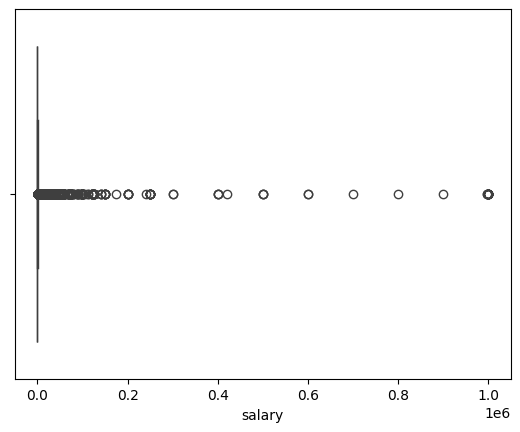

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_analysis['salary'])
plt.show()

In [17]:
Q1 = df_analysis['salary'].quantile(0.25)
Q3 = df_analysis['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

 OUTLIER REMOVAL

In [18]:
# Detect bounds
Q1 = df_analysis['salary'].quantile(0.25)
Q3 = df_analysis['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
df_analysis = df_analysis[
    (df_analysis['salary'] >= lower) &
    (df_analysis['salary'] <= upper)
].copy()

print("New max salary:", df_analysis['salary'].max())

New max salary: 223.0


RECHECK

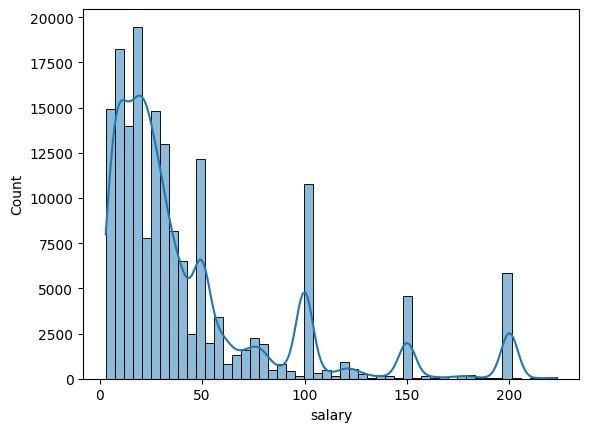

In [19]:
sns.histplot(df_analysis['salary'], bins=50, kde=True)
plt.show()

After removing outliers using the IQR method, the salary distribution became more interpretable. Most job postings offer salaries in the lower to mid range, with fewer high-paying opportunities, resulting in a right-skewed distribution.

## 4) EDA

 4.1 Dataset Overview

In [20]:
print("Shape:", df_analysis.shape)
print("\nColumns:\n", df_analysis.columns)
print("\nData Types:\n", df_analysis.dtypes)

Shape: (171835, 9)

Columns:
 Index(['title', 'link', 'published_date', 'is_hourly', 'country', 'hourly_avg',
       'salary', 'title_clean', 'job_category'],
      dtype='object')

Data Types:
 title                          object
link                           object
published_date    datetime64[ns, UTC]
is_hourly                        bool
country                        object
hourly_avg                    float64
salary                        float64
title_clean                    object
job_category                   object
dtype: object


 4.2 Salary Distribution

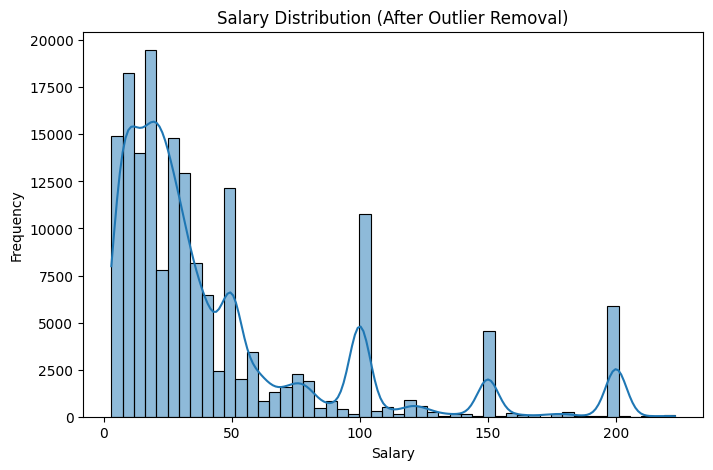

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df_analysis['salary'], bins=50, kde=True)

plt.title("Salary Distribution (After Outlier Removal)")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

 4.3 Job Category Distribution (VERY IMPORTANT)

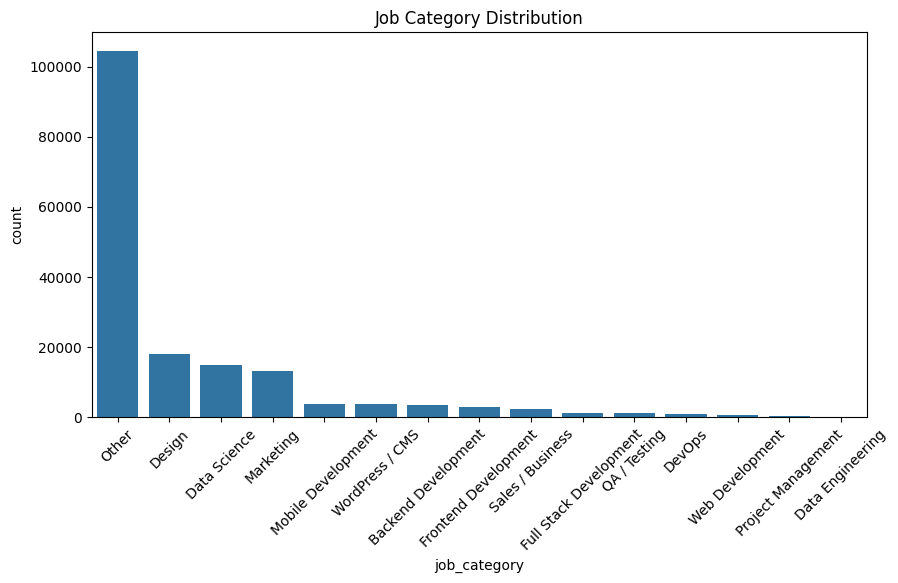

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_analysis,
    x='job_category',
    order=df_analysis['job_category'].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Job Category Distribution")
plt.show()

 4.4 Salary vs Job Category 

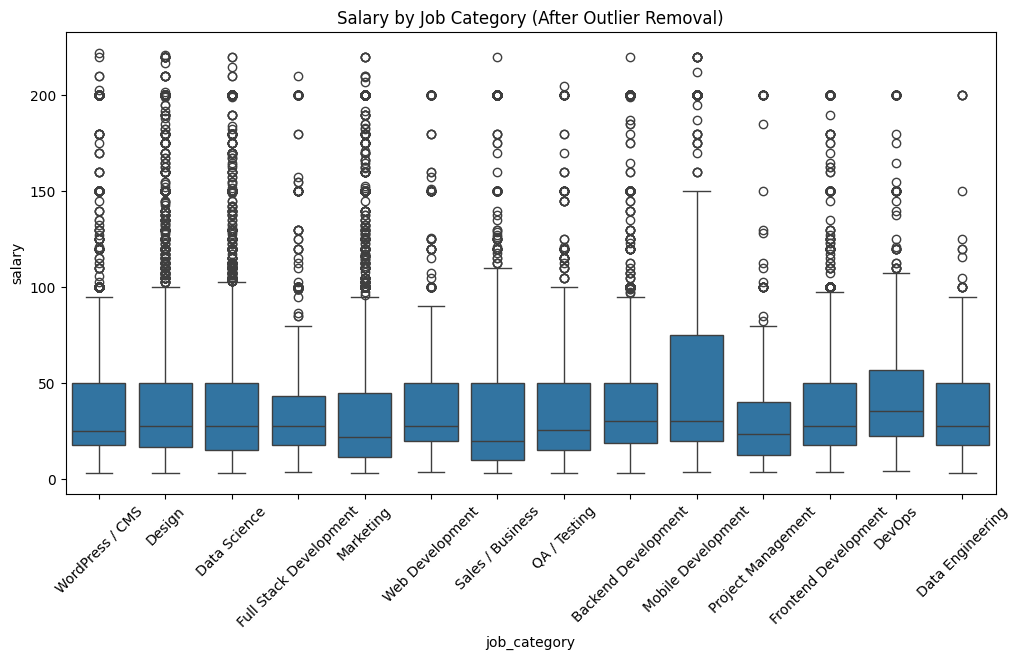

In [23]:
# Task 1: Analysis of Salary vs Job Categories
# Remove 'Other' category for better visualization
df_plot = df_analysis[df_analysis['job_category'] != 'Other']

plt.figure(figsize=(12,6))
sns.boxplot(data=df_plot, x='job_category', y='salary')

plt.xticks(rotation=45)
plt.title("Salary by Job Category (After Outlier Removal)")

plt.show()

 4.5 Top Job Titles

In [24]:
df_analysis['title'].value_counts().head(10)

title
Social Media Manager    306
Logo Design             252
Virtual Assistant       236
Graphic Designer        235
Video Editor            220
Logo design             146
Logo Designer           117
Full Stack Developer     95
Lead Generation          89
Video editor             86
Name: count, dtype: int64

 4.6 Country-wise Job Distribution

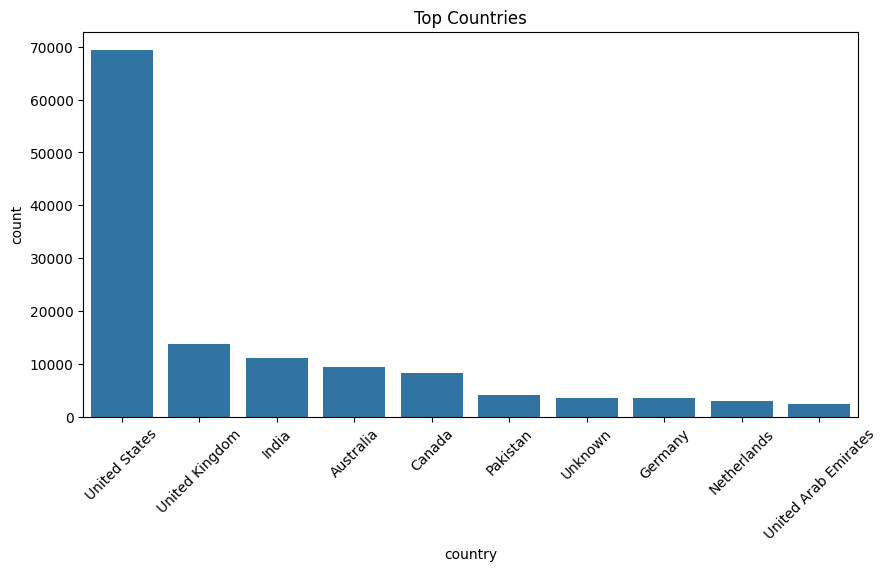

In [25]:
top_countries = df_analysis['country'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.countplot(
    data=df_analysis[df_analysis['country'].isin(top_countries)],
    x='country',
    order=top_countries
)

plt.xticks(rotation=45)
plt.title("Top Countries")
plt.show()

 4.7 Salary by Country

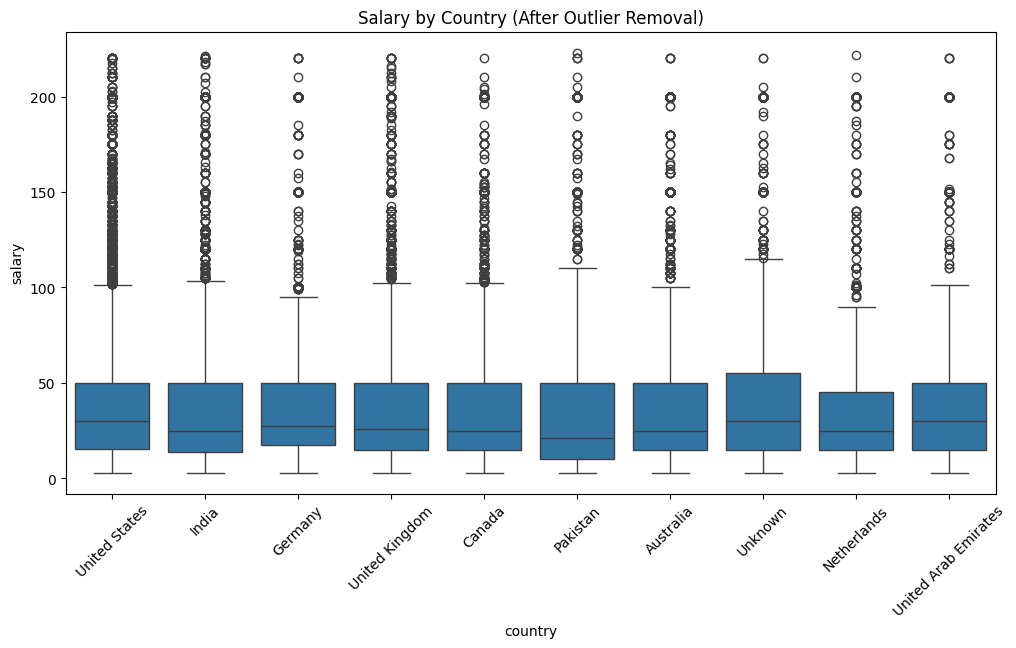

In [26]:
# Task 4: Comparison of Hourly Rates Across Countries

top_countries = df_analysis['country'].value_counts().head(10).index

df_country = df_analysis[df_analysis['country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_country, x='country', y='salary')

plt.xticks(rotation=45)
plt.title("Salary by Country (After Outlier Removal)")

plt.show()

 4.8 Jobs Over Time

In [27]:
# Task 6: Monthly Job Market Trends

df_analysis['published_date'] = pd.to_datetime(
    df_analysis['published_date'], 
    errors='coerce'
)

/var/folders/4t/rfy1gtv51td0t94_dwfrxy2c0000gn/T/ipykernel_24252/1056477318.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_analysis['month'] = df_analysis['published_date'].dt.to_period('M')


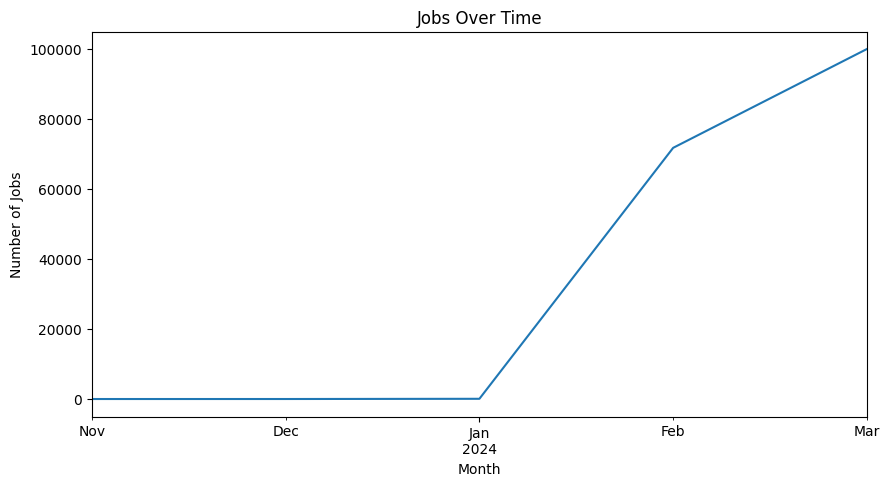

In [28]:
df_analysis['month'] = df_analysis['published_date'].dt.to_period('M')

jobs_per_month = df_analysis.groupby('month').size()

jobs_per_month.plot(figsize=(10,5))
plt.title("Jobs Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")
plt.show()

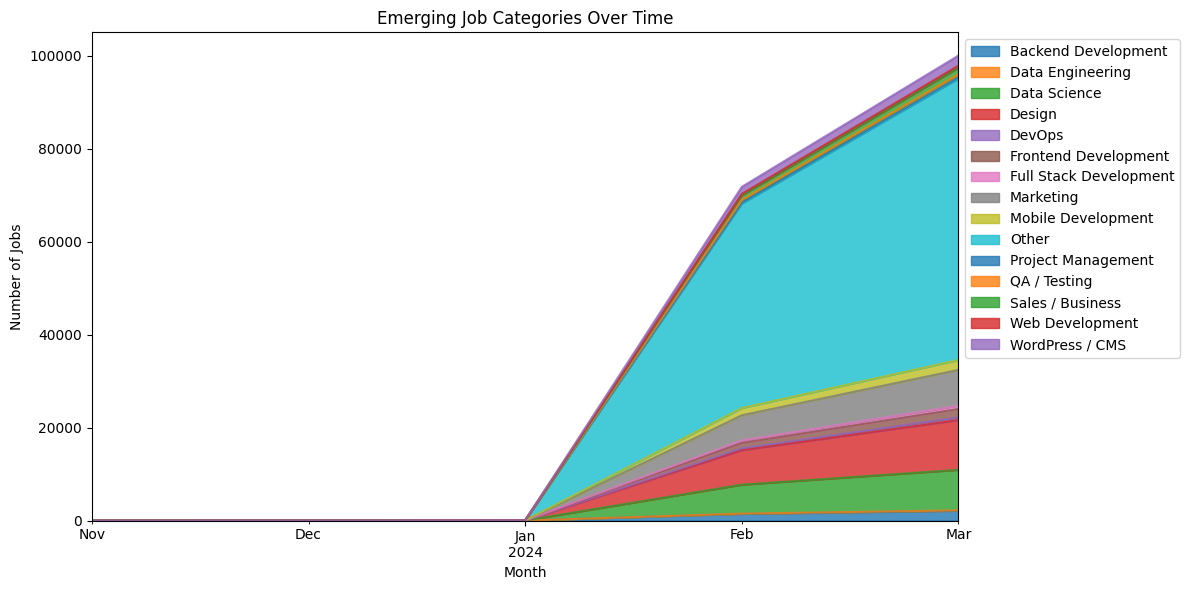

In [29]:
#  TASK 2: Category trend
category_trend = df_analysis.groupby(['month', 'job_category']).size().unstack().fillna(0)

category_trend.plot(
    kind='area',
    stacked=True,
    figsize=(12,6),
    alpha=0.8
)

plt.title("Emerging Job Categories Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Jobs")

plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

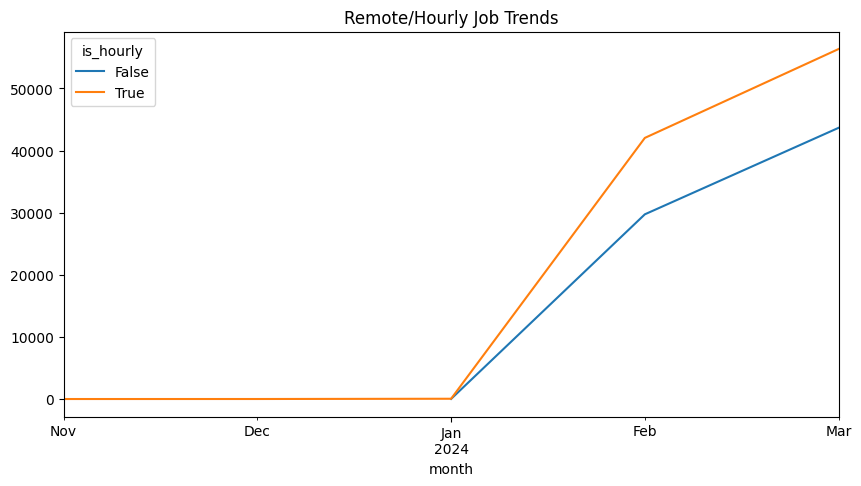

In [30]:
# TASK 7: Remote trend
remote_trend = df_analysis.groupby(['month', 'is_hourly']).size().unstack()

remote_trend.plot(figsize=(10,5))
plt.title("Remote/Hourly Job Trends")
plt.show()

In [31]:
# TASK 3 & 8: Demand prediction
from sklearn.linear_model import LinearRegression
import numpy as np

jobs_per_month = df_analysis.groupby('month').size()

X = np.arange(len(jobs_per_month)).reshape(-1,1)
y = jobs_per_month.values

model = LinearRegression()
model.fit(X, y)

future = np.arange(len(jobs_per_month), len(jobs_per_month)+5).reshape(-1,1)
pred = model.predict(future)

print("Future Job Demand:", pred)

Future Job Demand: [115894.1 143069.8 170245.5 197421.2 224596.9]


 4.9 Hourly vs Fixed Jobs

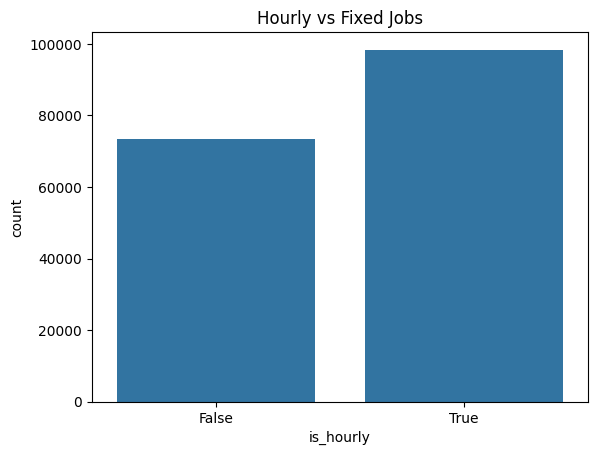

In [32]:
sns.countplot(data=df_analysis, x='is_hourly')
plt.title("Hourly vs Fixed Jobs")
plt.show()

 4.10 Correlation Analysis (IMPORTANT)

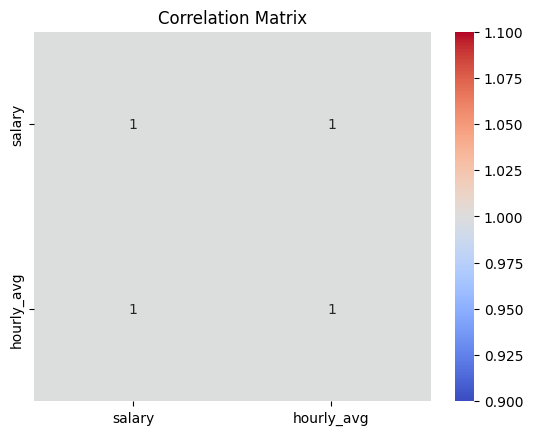

In [33]:
corr = df_analysis[['salary', 'hourly_avg']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 5) MACHINE LEARNING + RECOMMENDATION SYSTEM

 5.1 Prepare Data

In [34]:
# Select features
X = df_analysis[['job_category', 'country', 'is_hourly']]
y = df_analysis['salary']

5.2 Convert Categorical Data

In [35]:
X = pd.get_dummies(X, drop_first=True)

5.3 Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5.4 Train Models

In [37]:
import pandas as pd
import pickle

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}
trained_models = {}

# Train all models
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "R2": r2}
    trained_models[name] = model

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)

                         MAE        R2
Random Forest      28.663636  0.183238
Gradient Boosting  28.925942  0.180467
Decision Tree      28.690639  0.180349
Linear Regression  29.101348  0.175408
Ridge              29.100621  0.175404
Lasso              29.549180  0.153067


Select the best model

In [38]:
# Get best model name
best_model_name = results_df.index[0]

# Get best model object
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


SAVE BEST MODEL

In [39]:
import os

# Create folder if not exists
os.makedirs("/Users/windows/Desktop/Digichrome/Job_Market_Analysis_and_Recommendation_System/models", exist_ok=True)

# Now save model
with open("/Users/windows/Desktop/Digichrome/Job_Market_Analysis_and_Recommendation_System/models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [40]:
# Save model columns (VERY IMPORTANT)
with open("/Users/windows/Desktop/Digichrome/Job_Market_Analysis_and_Recommendation_System/models/model_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns, f)

5.5 Use TF-IDF

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df_recommendation['title_clean'])

5.6 Recommendation Function

In [42]:
# Task 5: Job Recommendation System

from sklearn.metrics.pairwise import cosine_similarity

def recommend_jobs(title, top_n=5):
    
    title = title.lower()
    
    # Find matching index
    idx = df_recommendation[
        df_recommendation['title_clean'].str.contains(title)
    ].index
    
    if len(idx) == 0:
        return "No matching job found"
    
    idx = idx[0]
    
    # Compute similarity ONLY for one job
    sim_scores = cosine_similarity(
        tfidf_matrix[idx], tfidf_matrix
    ).flatten()
    
    # Sort results
    sim_indices = sim_scores.argsort()[::-1][1:top_n+1]
    
    return df_recommendation.iloc[sim_indices][
        ['title', 'job_category', 'salary']
    ]